In [2]:
import sys
sys.path.append('../lib/')
import numpy as np
import healpy as hp
import pysm3
import pysm3.units as u
import pymaster as nmt
from scipy.ndimage import gaussian_filter
import pymaster as nmt
import matplotlib.pyplot as plt
import simu_lib as sim


In [33]:
# Load results dbsb

N = 250
nside = 64
lmax = 2*nside-1
Nlbin = 1
Npix = hp.nside2npix(nside)

results = np.load('../best_fits/results_dbsb_0.7_scale10_Nlbin1_Nmt-fg_gaussbeam_bandpass_ds_o1bts_analytical.npy', allow_pickle=True).item()
results10 = np.load('../best_fits/results_dbsb_0.7_scale10_Nlbin10_Nmt-fg_gaussbeam_bandpass_ds_o1bts_analytical.npy', allow_pickle=True).item()
#results10 = np.load('../best_fits/results_dbsb_0.7_scale10_Nmt-fg_gaussbeam_bandpass_ds_o1bts_fix1.npy', allow_pickle=True).item()

# PySM model to consider, d#s#

dust_type = 1
sync_type = 1
nside_pysm = 512
Npix_pysm = hp.nside2npix(nside_pysm)

# Reference frequencies in GHz

nu0d = 402
nu0s = 40

# Mask and workspace

mask = hp.read_map('../masks/mask_fsky0.7_nside64_aposcale10.npy')

b = nmt.NmtBin.from_lmax_linear(lmax, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()

b10 = nmt.NmtBin.from_lmax_linear(lmax, nlb=10, is_Dell=True)
leff10 = b10.get_effective_ells()

f = nmt.NmtField(mask, None, spin=2, lmax=lmax, purify_b=True)
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f, f, b)

In [34]:
# Compute dust moments maps

sky = pysm3.Sky(nside_pysm, preset_strings=[f'd{dust_type}'], output_unit=u.uK_CMB)
dust = sky.components[0]
beta_map = dust.mbb_index.value
T_map = dust.mbb_temperature.value

if dust_type == 12:
    A_map = dust.layers.value
    A_complex = (A_map[:,1] + 1j * A_map[:,2]) * func.unit_conversion(353, input_unit='uK_RJ', output_unit='uK_CMB') / func.mbb_uK(353, beta_map, 1/T_map, nu0=nu0d)
else:
    A_map = sky.get_emission(nu0d * u.GHz).value
    A_complex = np.array([A_map[1] + 1j * A_map[2]])
    beta_map = np.array([beta_map])
    T_map = np.array([T_map])

beta_bar = np.mean(results['beta_d'])
T_bar = np.mean(results['T_d'])

A_dg = sim.downgrade_map([np.zeros(Npix_pysm), A_complex[0].real, A_complex[0].imag], nside_in=512, nside_out=64)
w1b = np.sum(A_complex * (beta_map-beta_bar), axis=0)
w1b_dg = sim.downgrade_map([np.zeros(Npix_pysm), w1b.real, w1b.imag], nside_in=512, nside_out=64)

f1 = nmt.NmtField(mask, w1b_dg[1:], purify_b=True)
f2 = nmt.NmtField(mask, w1b_dg[1:], purify_b=True)
mom_th = sim.compute_master(f1, f2, w)[3]

In [35]:
beta_bar, T_bar

(np.float64(1.4799999999999998), np.float64(19.599999999999994))

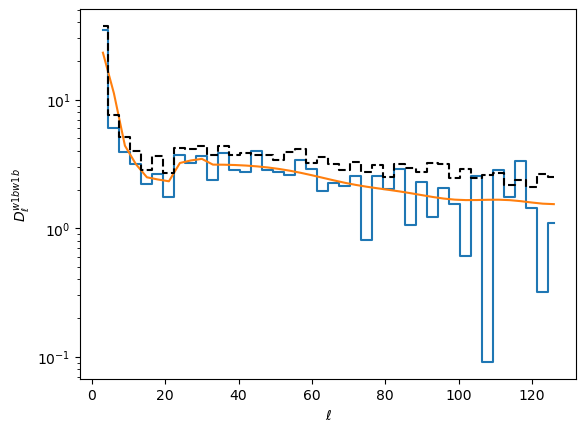

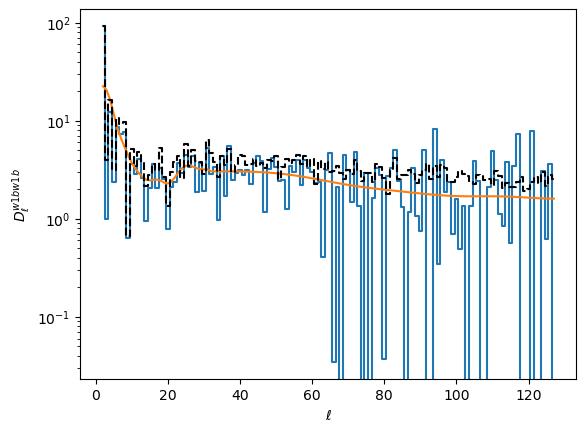

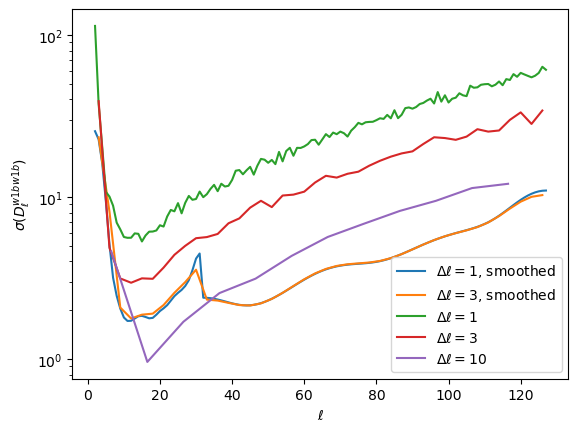

In [38]:
mom = 'w1bw1b'
transition = 30

DLmom = results[mom]
DLmom_smoothed = np.zeros_like(DLmom)
DLmom10 = results10[mom]

for k in range(N):
    DLmom_smoothed[:transition, k] = gaussian_filter(DLmom[:transition, k], sigma=2, mode='mirror')
    DLmom_smoothed[transition:, k] = gaussian_filter(DLmom[transition:, k], sigma=10, mode='mirror')


Nlbin_new = 3
transition_new = int(transition / Nlbin_new)
b_new = nmt.NmtBin.from_lmax_linear(lmax, nlb=Nlbin_new)
leff_new = b_new.get_effective_ells()
mom_th_new = b_new.bin_cell(np.concatenate((np.zeros(2), mom_th)))
DLmom_new = np.zeros((len(leff_new), N))
DLmom_smoothed_new = np.zeros_like(DLmom_new)
for k in range(N):
    DLmom_new[:, k] = b_new.bin_cell(np.concatenate((np.zeros(2), DLmom[:, k])))
    DLmom_smoothed_new[:transition_new, k] = gaussian_filter(DLmom_new[:transition_new, k], sigma=2/Nlbin_new, mode='mirror')
    DLmom_smoothed_new[transition_new:, k] = gaussian_filter(DLmom_new[transition_new:, k], sigma=10/Nlbin_new, mode='mirror')


plt.step(leff_new, np.mean(DLmom_new, axis=1), where='mid')
plt.plot(leff_new, np.mean(DLmom_smoothed_new, axis=1))
#plt.errorbar(leff, np.mean(DLmom, axis=1), yerr=np.std(DLmom, axis=1), fmt='o')
#plt.errorbar(leff, np.mean(DLmom_smoothed, axis=1), np.std(DLmom_smoothed, axis=1), fmt='o')
plt.step(leff_new, mom_th_new, linestyle='--', color='black', where='mid')
#plt.errorbar(leff10, np.mean(DLmom10, axis=1), yerr=np.std(DLmom10, axis=1), fmt='o')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{%s}$' % mom)
#plt.xscale('log')
plt.yscale('log')
plt.show()

plt.step(leff, np.mean(DLmom, axis=1), where='mid')
plt.plot(leff, np.mean(DLmom_smoothed, axis=1))
#plt.errorbar(leff, np.mean(DLmom, axis=1), yerr=np.std(DLmom, axis=1), fmt='o')
#plt.errorbar(leff, np.mean(DLmom_smoothed, axis=1), np.std(DLmom_smoothed, axis=1), fmt='o')
plt.step(leff, mom_th, linestyle='--', color='black', where='mid')
#plt.errorbar(leff10, np.mean(DLmom10, axis=1), yerr=np.std(DLmom10, axis=1), fmt='o')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{%s}$' % mom)
#plt.xscale('log')
plt.yscale('log')
plt.show()

plt.plot(leff, np.std(DLmom_smoothed, axis=1), label=r'$\Delta\ell = 1$, smoothed')
plt.plot(leff_new, np.std(DLmom_smoothed_new, axis=1), label=r'$\Delta\ell = %s$, smoothed' % Nlbin_new)
plt.plot(leff, np.std(DLmom, axis=1), label=r'$\Delta\ell = 1$')
plt.plot(leff_new, np.std(DLmom_new, axis=1), label=r'$\Delta\ell = %s$' % Nlbin_new)
plt.plot(leff10, np.std(DLmom10, axis=1), label=r'$\Delta\ell = 10$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\sigma(D_\ell^{%s})$' % mom)
plt.yscale('log')
plt.legend()
plt.show()

In [23]:
test = np.load('results_dbsb_0.7_scale10_Nlbin1_Nmt-fg_gaussbeam_bandpass_ds_o1bts_analytical.npy', allow_pickle=True).item()
Cl_lens = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')[2, :lmax+1]

Dl_lens = b.bin_cell(Cl_lens)
Dl_lens10 = b10.bin_cell(Cl_lens)

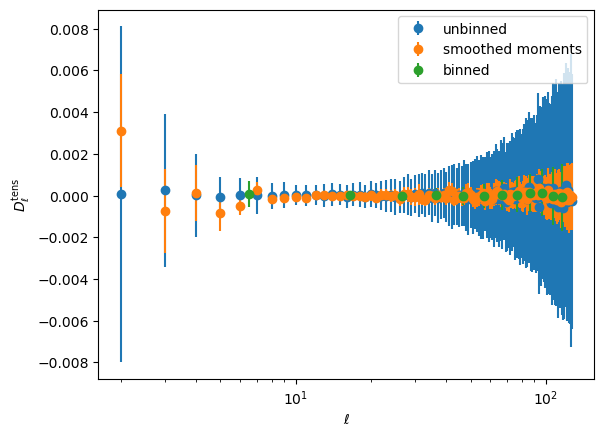

In [28]:
plt.errorbar(leff, np.mean(results['cmb'], axis=1) - Dl_lens, yerr=np.std(results['cmb'], axis=1), fmt='o', label='unbinned')
plt.errorbar(leff, np.mean(test['cmb'], axis=1) - Dl_lens, yerr=np.std(test['cmb'], axis=1), fmt='o', label='smoothed moments')
#plt.plot(leff, np.mean(test['cmb'], axis=1) - Dl_lens, label='smoothed moments')
plt.errorbar(leff10, np.mean(results10['cmb'], axis=1) - Dl_lens10, yerr=np.std(results10['cmb'], axis=1), fmt='o', label='binned')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{\rm tens}$')
plt.xscale('log')
#plt.yscale('log')
plt.legend()
plt.show()